In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
from sbi.inference import MCMCPosterior
from scipy.special import logsumexp
from seaborn import histplot

import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import SLCP, SLCP_wrapper
import sbibm
from seaborn import pairplot
import warnings
warnings.simplefilter('ignore', FutureWarning)

import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize

task = sbibm.get_task('slcp')
prior = task.get_prior_dist()
t = task.get_true_parameters(10)
X = SLCP_wrapper(reps=10, parameters=t)

In [33]:
posterior_cp = pickle.load(open('posteriors/posterior_SLCP_100000_20.pkl', 'rb'))
epsilon = -10
op = CollectivePosterior(prior,X, posterior_cp, 1, epsilon, n_eval=100_000)
print(op.get_log_C())

tensor(48.1834)


MCMC from top 50 candidates: 100%|██████████| 1000/1000 [00:10<00:00, 89.96it/s]


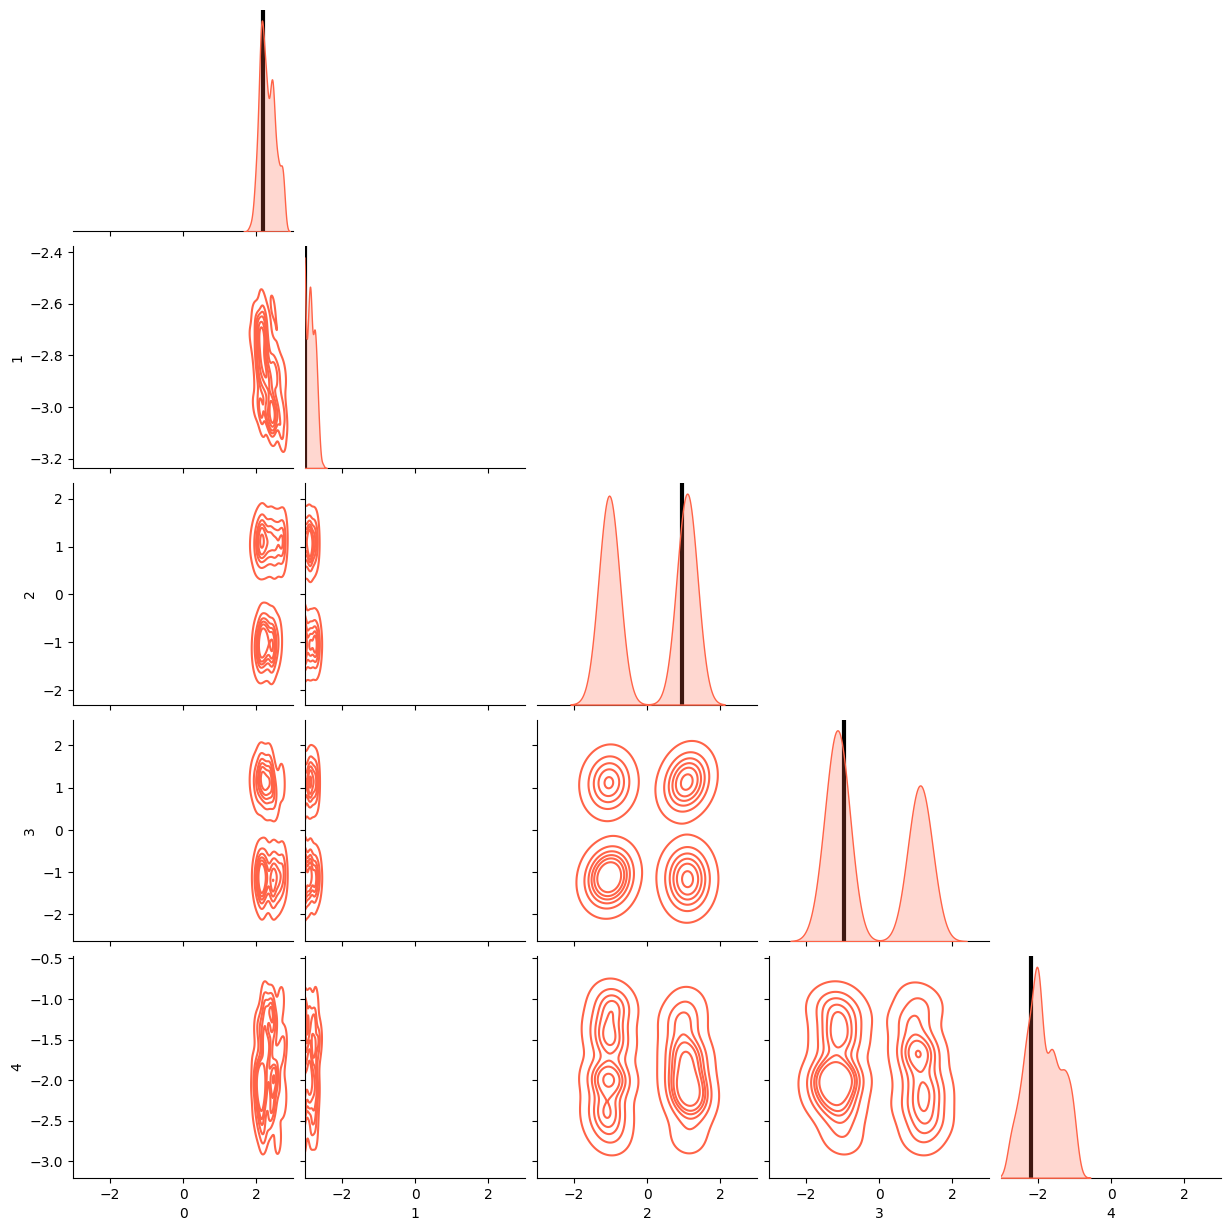

In [34]:
samples_collective = pd.DataFrame(op.sample(1000).numpy())
g = pairplot(samples_collective, kind='kde', plot_kws = {'levels': 7, 'color':'tomato'}, diag_kws={'color':'tomato'}, corner=True)
for i in range(len(t[0])):
    g.axes[i,i].axvline(t[0][i].item(),color='k', linewidth=3)
    g.axes[i,i].set_xlim(prior.base_dist.low[i], prior.base_dist.high[i])

In [36]:
t

tensor([[ 2.1796, -2.9841,  0.9612, -0.9603, -2.1850]])

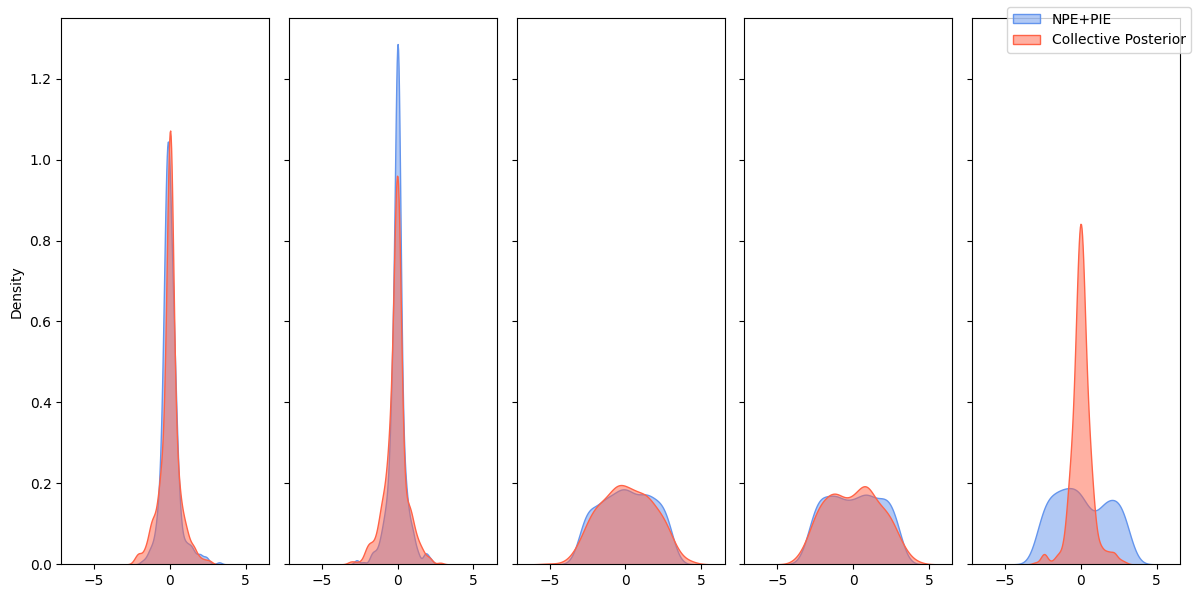

In [2]:
from seaborn import  kdeplot

def plot_accuracy(acc_path, ax, color, label):
    for i in range(len(ax)):
        kdeplot(res[:,i],ax=ax[i], color=color, fill=True, alpha=0.5, label=label if i==0 else None)
    return

n_params=5
fig, ax = plt.subplots(1,n_params, figsize=(12,6), tight_layout=True, sharex=True, sharey=True)


cp_acc = 'tests/accus_SLCP_iid.pt'
res = torch.load(cp_acc)
plot_accuracy(res, ax, color='cornflowerblue', label='NPE+PIE')

cp_acc = 'tests/accus_SLCP_eps-10.pt'
res = torch.load(cp_acc)
plot_accuracy(res, ax, color='tomato', label='Collective Posterior')
fig.legend()

In [3]:
conf_levels = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95]
covs_cp = pd.DataFrame(torch.load('tests/covs_SLCP_eps-10.pt').mean(dim=0).numpy(), index=conf_levels)
# covs_cp.to_excel('tests/covs_SLCP.xlsx')
covs_cp

,0,1,2,3,4
0.10,0.106,0.108,0.098,0.108,0.110
0.20,0.212,0.224,0.234,0.228,0.214
0.30,0.340,0.316,0.360,0.346,0.306
0.40,0.454,0.432,0.480,0.470,0.406
0.50,0.548,0.518,0.576,0.558,0.474
0.60,0.616,0.624,0.666,0.638,0.534
0.70,0.694,0.680,0.724,0.724,0.616
0.80,0.772,0.750,0.796,0.808,0.704
0.90,0.818,0.810,0.868,0.872,0.794
0.95,0.856,0.864,0.890,0.908,0.832


In [4]:
covs_iid = pd.DataFrame(torch.load('tests/covs_SLCP_iid.pt').mean(dim=0).numpy(), index=conf_levels)
# covs_iid.to_excel('tests/covs_SLCP_iid.xlsx')
covs_iid

,0,1,2,3,4
0.10,0.088,0.110,0.104,0.088,0.090
0.20,0.198,0.210,0.228,0.174,0.192
0.30,0.282,0.328,0.326,0.240,0.270
0.40,0.396,0.450,0.424,0.346,0.332
0.50,0.486,0.530,0.526,0.464,0.422
0.60,0.604,0.622,0.634,0.576,0.532
0.70,0.702,0.728,0.704,0.686,0.604
0.80,0.792,0.810,0.784,0.784,0.700
0.90,0.882,0.912,0.866,0.888,0.818
0.95,0.928,0.958,0.934,0.936,0.894


In [5]:
# Compute the proportion of elements where covs_cp is greater than covs_iid
((covs_cp - covs_iid) > 0).mean(axis=None)

0.64

In [16]:
# plot accuracy in 2X3 axis
def plot_accuracy(acc, ax, color, label, hatch):
    parameters = ['$\\theta_1$', '$\\theta_2$', '$\\theta_3$', '$\\theta_4$', '$\\theta_5$']
    for i in range(len(ax)):

        kdeplot(acc[:,i],ax=ax[i], color=color, alpha=0.7, fill=True)
        ax[i].axvline(0, color='k', lw=1.7, ls='--')
        ax[i].set_xlabel(parameters[i])
        ax[i].set_ylim(0,1.3)
    return

conf_levels = np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95], dtype=float)
def plot_covs(ax, covs1, covs2):
    """
    Plot mean coverage across parameters (and repeats) with error bars showing
    variability among parameters.

    Expects covs arrays of shape (n_repeats, n_conf, n_params) or (n_conf, n_params).
    """
    import numpy as np

    def to_np(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    a1 = to_np(covs1)
    a2 = to_np(covs2)

    # normalize shapes to (n_repeats, n_conf, n_params)
    if a1.ndim == 2:
        a1 = a1[None, ...]
    if a2.ndim == 2:
        a2 = a2[None, ...]

    n_reps, n_conf, n_params = a1.shape

    # For each confidence level, compute per-parameter mean across repeats,
    # then compute the mean across parameters (value to plot) and the std across parameters
    mean1 = np.empty(n_conf)
    sd1 = np.empty(n_conf)
    mean2 = np.empty(n_conf)
    sd2 = np.empty(n_conf)

    for j in range(n_conf):
        # shape (n_reps, n_params) -> mean over repeats -> (n_params,)
        per_param_mean1 = a1[:, j, :].mean(axis=0)
        per_param_mean2 = a2[:, j, :].mean(axis=0)
        # mean across parameters
        mean1[j] = per_param_mean1.mean()
        mean2[j] = per_param_mean2.mean()
        # variability among parameters (std). Use std (not se) as requested.
        sd1[j] = per_param_mean1.std(ddof=0)
        sd2[j] = per_param_mean2.std(ddof=0)

    palette = {'Collective Posterior': 'tomato', 'NPE+PIE': 'cornflowerblue'}

    ax.errorbar(conf_levels, mean1, yerr=sd1, label='Collective Posterior',
                color=palette['Collective Posterior'], marker='o', linestyle='-', capsize=10, linewidth=5)
    ax.errorbar(conf_levels, mean2, yerr=sd2, label='NPE+PIE',
                color=palette['NPE+PIE'], marker='s', linestyle='--', capsize=10, linewidth=5)
    ax.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color='k', linestyle='--', label='Ideal')
    ax.legend(fontsize=40)



Text(0, 0.5, '')

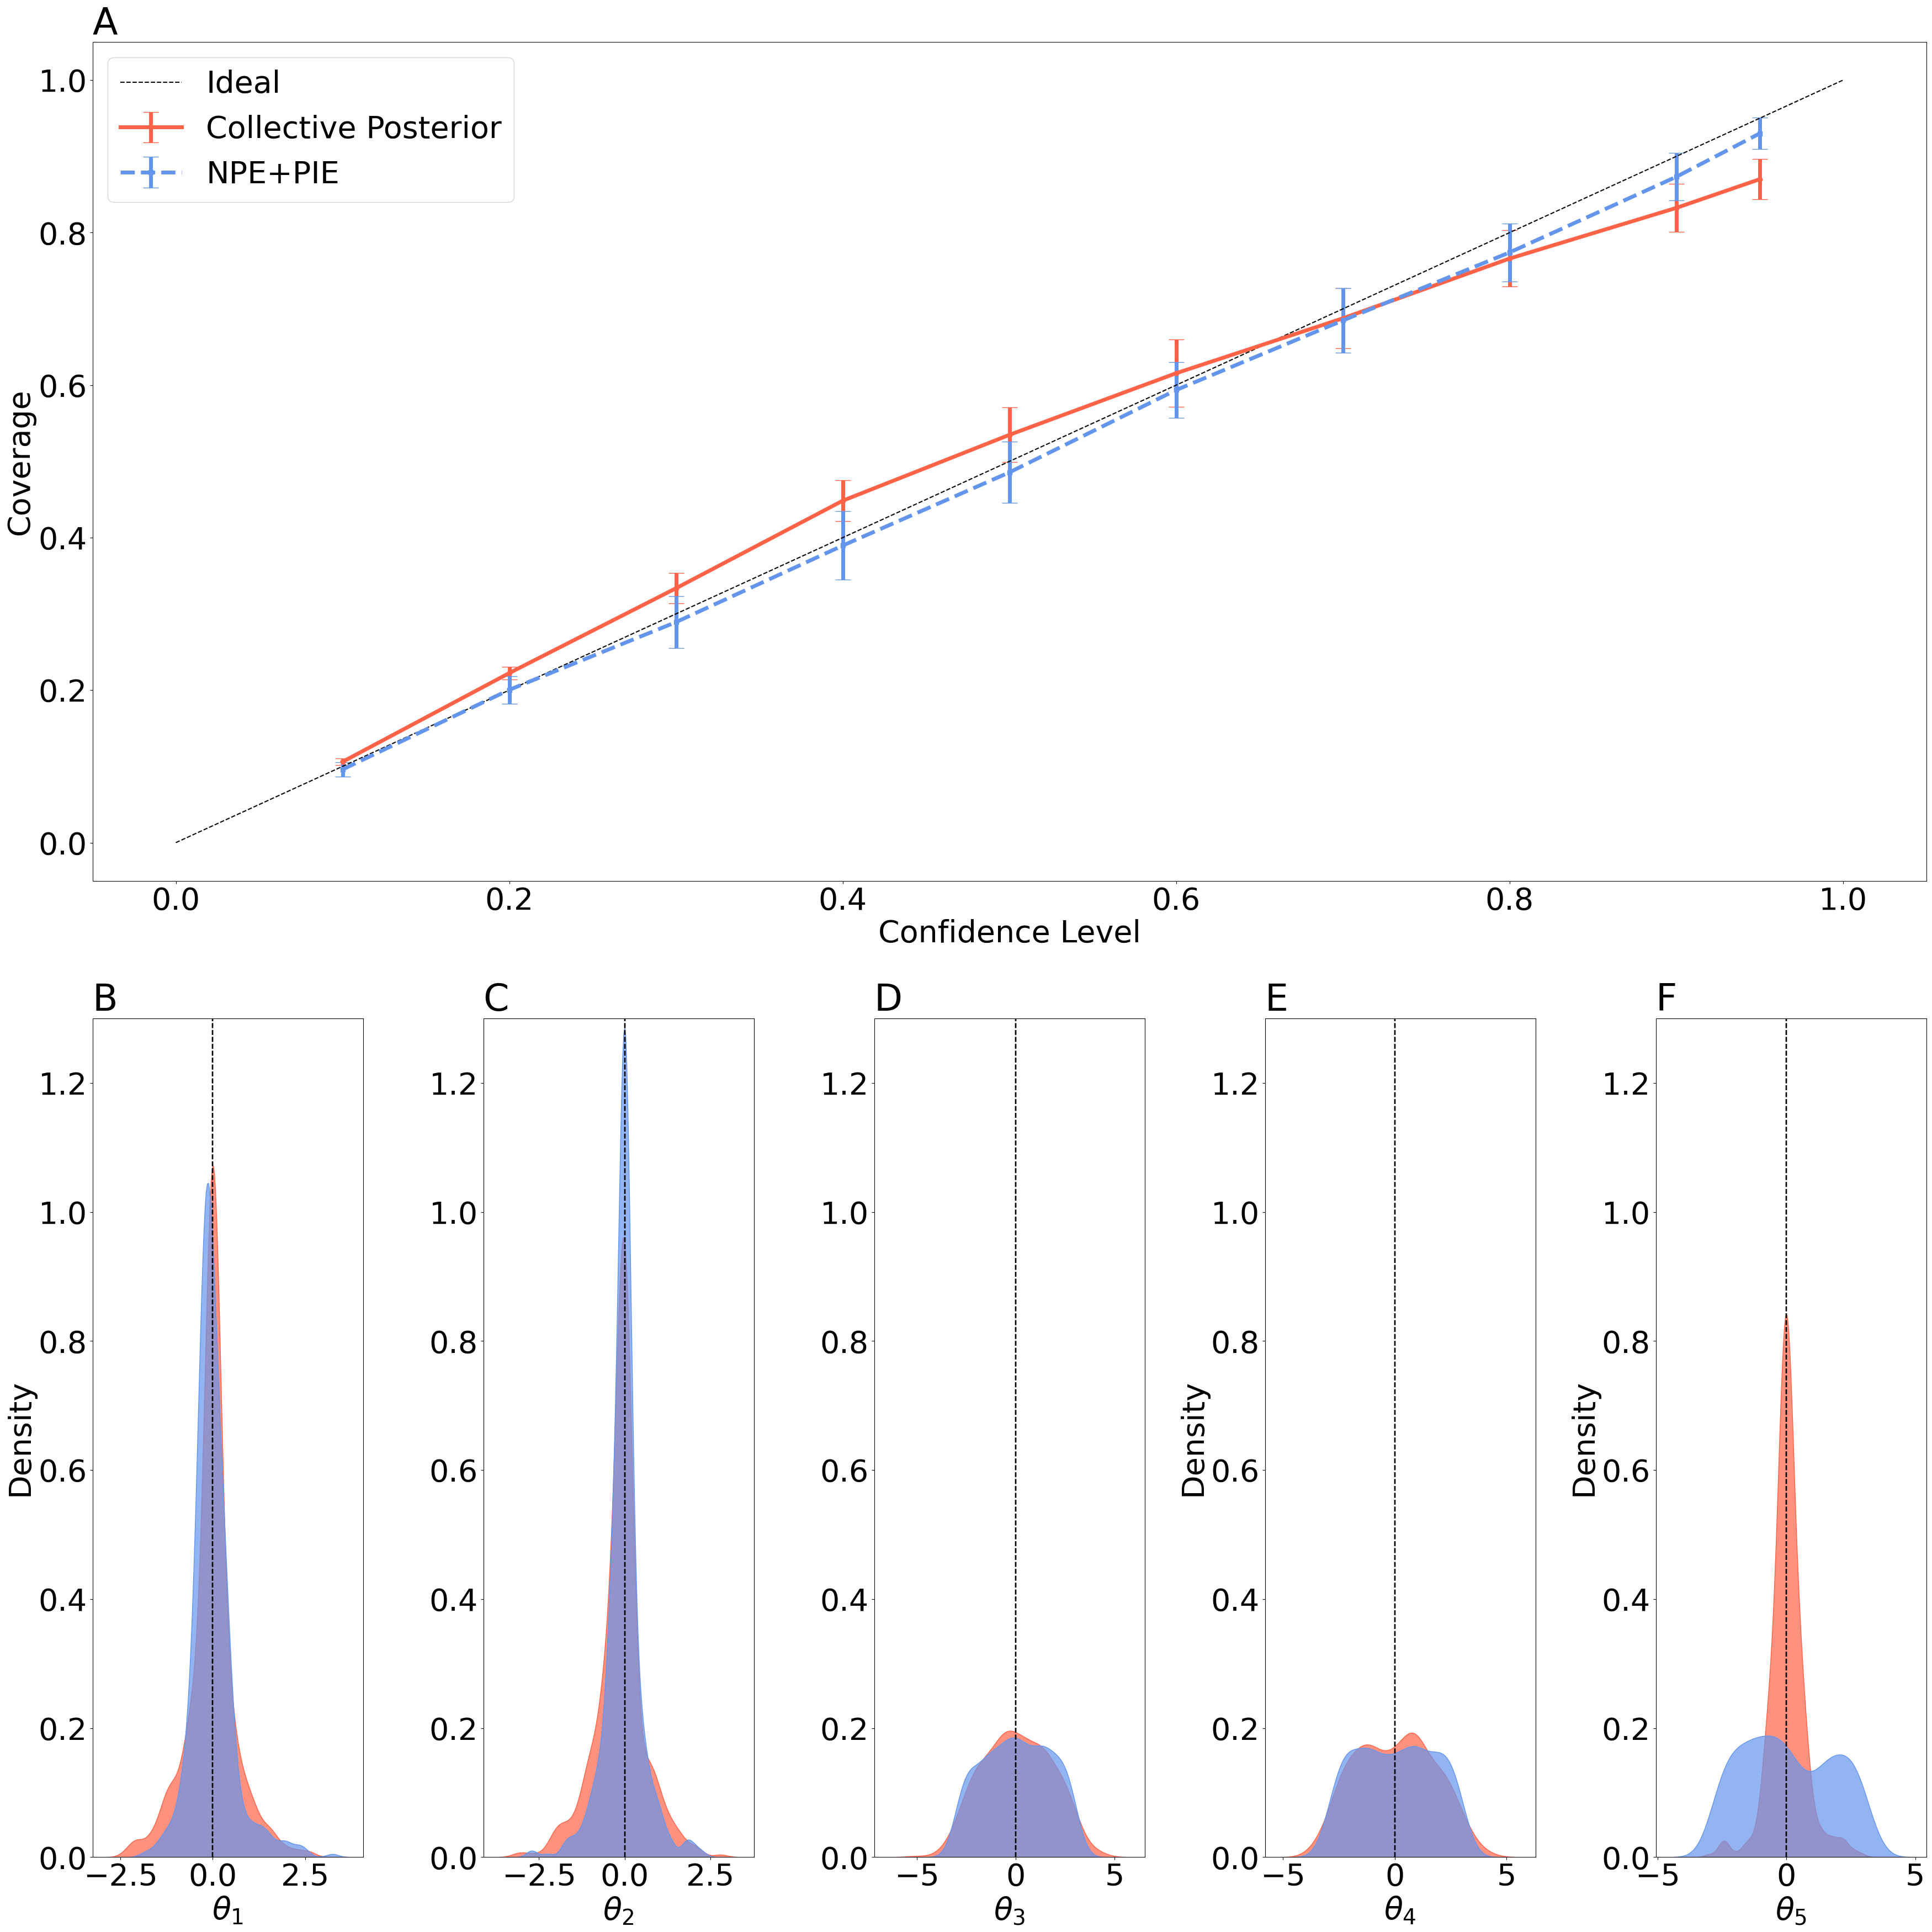

In [17]:
change_font(40)

mosaic = '''AAAAA
            BCDEF
            '''
fig, ax = plt.subplot_mosaic(mosaic,figsize=(36,36), tight_layout=True)
ax['A'].set_title('A',loc='left')
ax['B'].set_title('B',loc='left')
ax['C'].set_title('C',loc='left')
ax['D'].set_title('D',loc='left')
ax['E'].set_title('E',loc='left')
ax['F'].set_title('F',loc='left')

# Coverage plots in ax B
covs = torch.load(f'tests/covs_SLCP_eps-10.pt')
covs_iid = torch.load(f'tests/covs_SLCP_iid.pt')
plot_covs(ax=ax['A'], covs1=covs.numpy(), covs2=covs_iid.numpy())
ax['A'].set_xlabel('Confidence Level')
ax['A'].set_ylabel('Coverage')
# Accuracy plots in ax C-E
n_params=6


axx = [ax['B'], ax['C'], ax['D'], ax['E'], ax['F']]

cp_acc = torch.load('tests/accus_SLCP_eps-10.pt')
plot_accuracy(cp_acc, axx, color='tomato', hatch='', label='Collective\nPosterior')


iid_acc = torch.load('tests/accus_SLCP_iid.pt')
plot_accuracy(iid_acc, axx, color='cornflowerblue', hatch='', label='NPE+PIE')

# ax['A'].legend(loc='upper left')
ax['C'].set_ylabel('')
ax['D'].set_ylabel('')
